# 🛍️ Mall Customer Segmentation — K-Means vs Hierarchical vs DBSCAN

---

| Detail | Info |
|--------|------|
| **Domain** | Retail / Marketing Analytics |
| **Technique** | Unsupervised Learning — Clustering |
| **Dataset** | Mall Customers — 200 records |
| **Features Used** | Annual Income (k$) · Spending Score (1-100) |
| **Algorithms Compared** | K-Means · Hierarchical (Agglomerative) · DBSCAN |
| **Optimal Clusters** | 5 (K-Means & Hierarchical) |

---

## 🎯 Business Objective

> **Segment mall customers into meaningful groups** based on their annual income and spending behaviour — so the marketing team can design **targeted campaigns** for each customer type.

**Real-World Impact:**
- 🎯 **Targeted marketing** — different promotions for different customer segments
- 💰 **Revenue optimisation** — focus high-value efforts on high-spending customers
- 🛍️ **Product placement** — stock premium products near high-income zones
- 📊 **Customer lifetime value** — identify and retain loyal high-value customers

---

## 🧠 Clustering vs Classification — Key Difference

| | Classification (Supervised) | Clustering (Unsupervised) |
|--|------|------|
| **Labels** | Given (we know the answer) | Unknown (we discover groups) |
| **Goal** | Predict a known category | Find hidden structure in data |
| **Example** | spam/not spam | Which customers are similar? |

> 🔑 **Clustering is unsupervised** — there's no target variable.
> The algorithm discovers natural groupings purely from data patterns.

---

## 📊 Three Algorithms — When to Use Which

| Algorithm | How It Works | Best For | Weakness |
|-----------|-------------|----------|----------|
| **K-Means** | Assign points to nearest centroid, update centroids | Round/spherical clusters, large data | Must specify K; sensitive to outliers |
| **Hierarchical** | Merge closest clusters bottom-up (Ward linkage) | When K is unknown; creates dendrogram | Slow on large data (O(n³)) |
| **DBSCAN** | Expand clusters from dense core points | Irregular shapes; outlier detection | Struggles with varying density |

---

## 🗺️ Project Workflow

```
Load Mall Customers Dataset (200 records)
              ↓
EDA — Distributions, Correlations, Boxplots
              ↓
Feature Selection + Preprocessing (StandardScaler)
              ↓
┌──────────────────────────────────────────────┐
│  Algorithm 1: K-Means                        │
│    → Elbow Method → Optimal K=5              │
│    → Fit + Visualise 5 Clusters              │
└──────────────────────────────────────────────┘
              ↓
┌──────────────────────────────────────────────┐
│  Algorithm 2: Hierarchical Clustering        │
│    → Dendrogram → Optimal K=5                │
│    → Agglomerative + Visualise               │
└──────────────────────────────────────────────┘
              ↓
┌──────────────────────────────────────────────┐
│  Algorithm 3: DBSCAN                         │
│    → k-NN distance plot → eps tuning         │
│    → Fit + Show noise points                 │
└──────────────────────────────────────────────┘
              ↓
Algorithm Comparison + Business Recommendations
```

## 1️⃣ Import Libraries


In [1]:
# ── Data & Visualisation ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Clustering Algorithms ──
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as sch

# ── Display Settings ──
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries loaded!')


✅ All libraries loaded!


## 2️⃣ Load & Explore the Dataset

### 📊 Mall Customers Dataset

| Feature | Type | Description |
|---------|------|-------------|
| `CustomerID` | ID | Unique customer identifier (dropped) |
| `Genre` | Categorical | Male / Female (dropped for this analysis) |
| `Age` | Numerical | Customer age in years (dropped for this analysis) |
| `Annual Income (k$)` | **Feature** | Yearly income in thousands of dollars |
| `Spending Score (1-100)` | **Feature** | Mall-assigned score based on spending behaviour |

> 🎯 **Why only Income + Spending Score?**
> These two features create the most meaningful and visually interpretable customer segments.
> The classic 'Income vs Spending' matrix reveals 5 natural customer archetypes.


In [2]:
# Load dataset
df_raw = pd.read_csv('Mall_Customers.csv')

print(f'📊 Shape: {df_raw.shape}')
print(f'📋 Columns: {list(df_raw.columns)}')
print(f'🔍 Missing values: {df_raw.isnull().sum().sum()}')
print(f'🔁 Duplicates: {df_raw.duplicated().sum()}')
df_raw.head()


📊 Shape: (200, 5)
📋 Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
🔍 Missing values: 0
🔁 Duplicates: 0


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Statistical summary
print('📊 Statistical Summary:')
df_raw.describe().round(2)


📊 Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


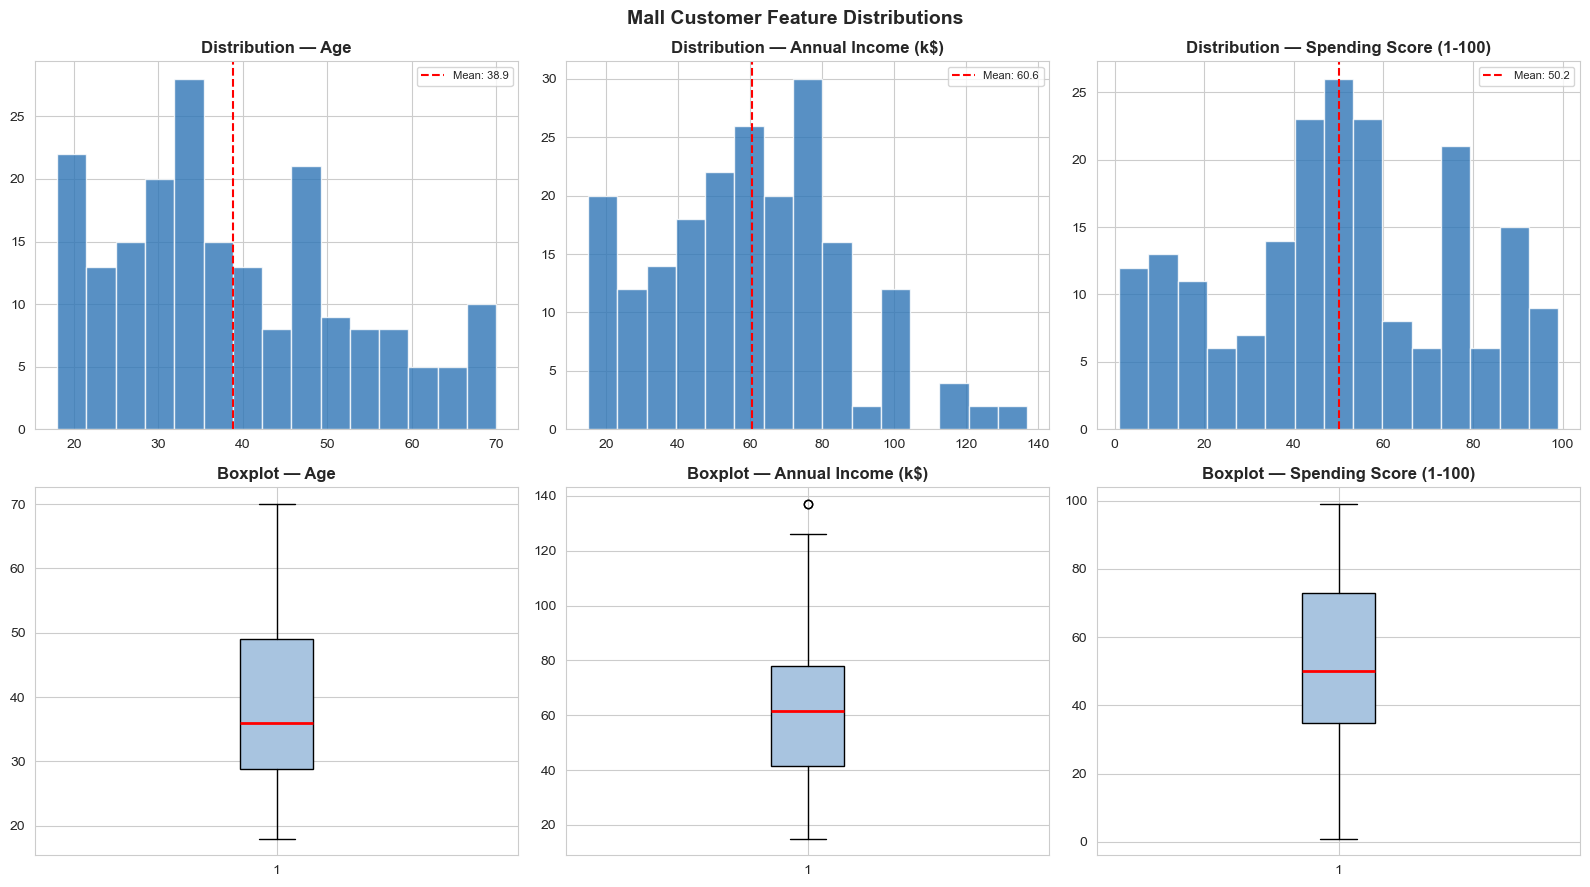

In [4]:
# EDA — Distributions and relationships
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Distribution plots
for i, col in enumerate(['Age','Annual Income (k$)','Spending Score (1-100)']):
    axes[0,i].hist(df_raw[col], bins=15, color='#2E75B6', edgecolor='white', alpha=0.8)
    axes[0,i].axvline(df_raw[col].mean(), color='red', linestyle='--',
                      label=f'Mean: {df_raw[col].mean():.1f}')
    axes[0,i].set_title(f'Distribution — {col}', fontweight='bold')
    axes[0,i].legend(fontsize=8)

# Boxplots
for i, col in enumerate(['Age','Annual Income (k$)','Spending Score (1-100)']):
    axes[1,i].boxplot(df_raw[col], patch_artist=True,
                      boxprops=dict(facecolor='#a8c4e0'),
                      medianprops=dict(color='red', linewidth=2))
    axes[1,i].set_title(f'Boxplot — {col}', fontweight='bold')

plt.suptitle('Mall Customer Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


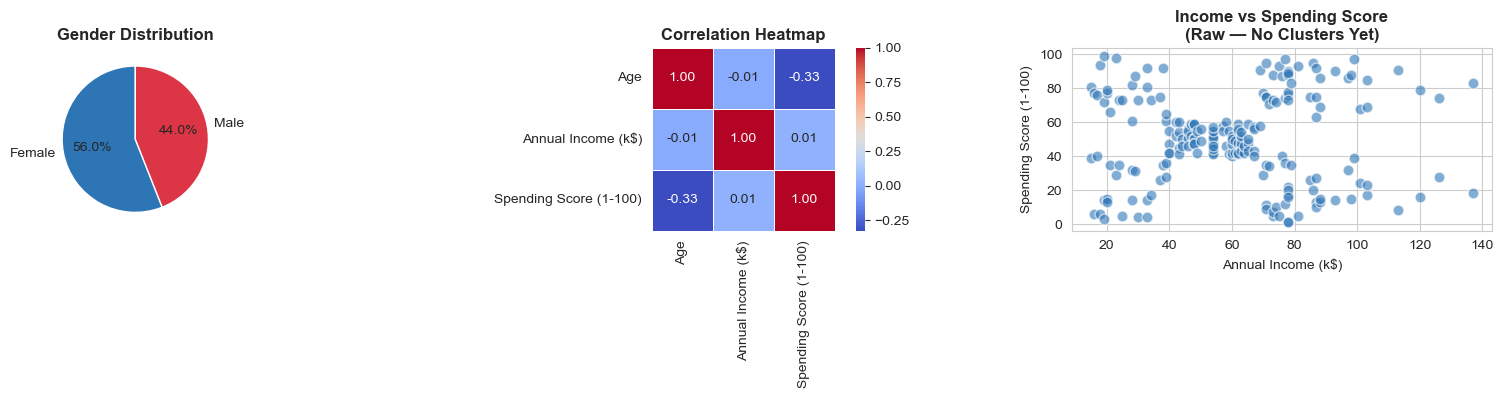

📌 Key Observations:
   - Low correlation between features → good for clustering (independent dimensions)
   - Raw scatter shows 5 natural cluster regions visible to the human eye
   - Age has weak correlation with spending — excluded from clustering


In [5]:
# Gender distribution + Correlation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gender
genre_counts = df_raw['Genre'].value_counts()
axes[0].pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%',
            colors=['#2E75B6','#dc3545'], startangle=90)
axes[0].set_title('Gender Distribution', fontweight='bold')

# Correlation heatmap
corr = df_raw[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1],
            linewidths=0.5, square=True)
axes[1].set_title('Correlation Heatmap', fontweight='bold')

# Income vs Spending (raw)
axes[2].scatter(df_raw['Annual Income (k$)'], df_raw['Spending Score (1-100)'],
                alpha=0.6, color='#2E75B6', edgecolors='white', s=60)
axes[2].set_xlabel('Annual Income (k$)')
axes[2].set_ylabel('Spending Score (1-100)')
axes[2].set_title('Income vs Spending Score\n(Raw — No Clusters Yet)', fontweight='bold')

plt.tight_layout()
plt.show()

print('📌 Key Observations:')
print('   - Low correlation between features → good for clustering (independent dimensions)')
print('   - Raw scatter shows 5 natural cluster regions visible to the human eye')
print('   - Age has weak correlation with spending — excluded from clustering')


## 3️⃣ Feature Selection & Preprocessing

### Why StandardScaler?

All 3 clustering algorithms are **distance-based** — they measure how far apart points are.
If features have different scales, the larger-scale feature dominates:

```
Annual Income : ranges 15 → 137  (range = 122)
Spending Score: ranges 1  → 99   (range = 98)

→ Similar scale here, but StandardScaler still ensures fair distance calculation.
```

**StandardScaler formula:**
```
z = (x - mean) / std
→ Result: mean=0, std=1 for every feature
```


In [6]:
# Drop ID and demographic columns (not used for segmentation)
df = df_raw.drop(['CustomerID','Genre','Age'], axis=1).copy()

print(f'Features for clustering: {list(df.columns)}')

# Extract feature array
X = df[['Annual Income (k$)','Spending Score (1-100)']].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nOriginal feature ranges:')
print(f'  Annual Income  : {X[:,0].min():.0f} → {X[:,0].max():.0f}')
print(f'  Spending Score : {X[:,1].min():.0f} → {X[:,1].max():.0f}')
print(f'\nAfter scaling (mean≈0, std≈1):')
print(f'  Annual Income  : {X_scaled[:,0].min():.2f} → {X_scaled[:,0].max():.2f}  (mean={X_scaled[:,0].mean():.4f})')
print(f'  Spending Score : {X_scaled[:,1].min():.2f} → {X_scaled[:,1].max():.2f}  (mean={X_scaled[:,1].mean():.4f})')
print(f'\n✅ Scaling complete — all algorithms will use X_scaled')


Features for clustering: ['Annual Income (k$)', 'Spending Score (1-100)']

Original feature ranges:
  Annual Income  : 15 → 137
  Spending Score : 1 → 99

After scaling (mean≈0, std≈1):
  Annual Income  : -1.74 → 2.92  (mean=-0.0000)
  Spending Score : -1.91 → 1.89  (mean=-0.0000)

✅ Scaling complete — all algorithms will use X_scaled


---

# 🔵 Algorithm 1 — K-Means Clustering

## How K-Means Works

```
Step 1: Randomly place K centroids in feature space
Step 2: Assign every point to its nearest centroid
Step 3: Recalculate centroid = mean of all points in cluster
Step 4: Repeat Steps 2-3 until centroids stop moving
```

**k-means++ initialisation** (used here):
Instead of random initialisation, k-means++ places centroids spread apart → much better convergence!

### ❓ How Many Clusters? — The Elbow Method

K-Means requires us to **specify K in advance**.
The **Elbow Method** helps find the optimal K:

```
WCSS = Within-Cluster Sum of Squares
     = Sum of (distance from each point to its centroid)²

More clusters → lower WCSS (always)
But at some K, adding more clusters gives diminishing returns
→ That 'elbow' point = optimal K
```


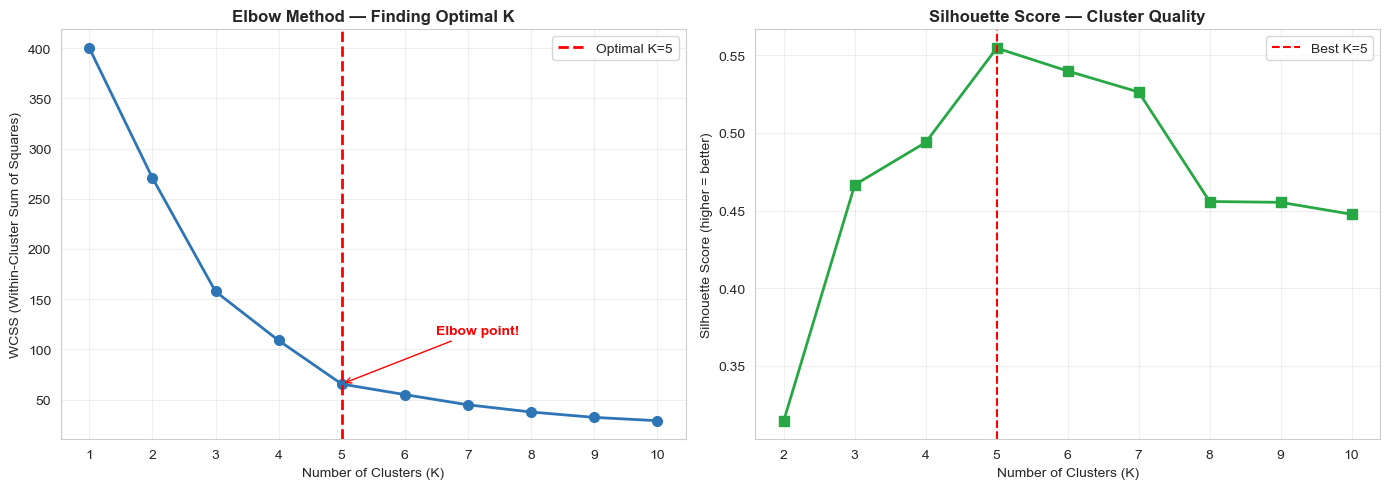

✅ Optimal K = 5 (confirmed by both Elbow method and Silhouette score)
   Best Silhouette Score at K=5: 0.5547

📌 Silhouette Score interpretation:
   ~1.0 = Perfect separation  |  ~0.5 = Reasonable  |  ~0.0 = Overlapping clusters


In [7]:
# ── Elbow Method: Find Optimal K ──
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(range(1, 11), wcss, 'o-', color='#2E75B6', linewidth=2, markersize=7)
axes[0].axvline(5, color='red', linestyle='--', linewidth=2, label='Optimal K=5')
axes[0].set_title('Elbow Method — Finding Optimal K', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)')
axes[0].set_xticks(range(1, 11))
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].annotate('Elbow point!', xy=(5, wcss[4]),
                 xytext=(6.5, wcss[4]+50),
                 fontsize=10, color='red', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='red'))

# Silhouette scores
axes[1].plot(list(K_range), silhouette_scores, 's-', color='#28a745', linewidth=2, markersize=7)
best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score — Cluster Quality', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_xticks(list(K_range))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'✅ Optimal K = 5 (confirmed by both Elbow method and Silhouette score)')
print(f'   Best Silhouette Score at K={best_k}: {max(silhouette_scores):.4f}')
print(f'\n📌 Silhouette Score interpretation:')
print(f'   ~1.0 = Perfect separation  |  ~0.5 = Reasonable  |  ~0.0 = Overlapping clusters')


In [8]:
# ── Fit K-Means with K=5 ──
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add to dataframe
df_kmeans = df.copy()
df_kmeans['Cluster'] = y_kmeans

print(f'✅ K-Means fitted!')
print(f'Cluster distribution:')
for c, cnt in df_kmeans['Cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c}: {cnt} customers')

# Cluster centroids (in original scale)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
print(f'\nCluster Centroids (original scale):')
cent_df = pd.DataFrame(centroids_original,
                        columns=['Annual Income (k$)','Spending Score (1-100)'])
cent_df.index.name = 'Cluster'
print(cent_df.round(1))


✅ K-Means fitted!
Cluster distribution:
  Cluster 0: 81 customers
  Cluster 1: 35 customers
  Cluster 2: 23 customers
  Cluster 3: 22 customers
  Cluster 4: 39 customers

Cluster Centroids (original scale):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                      55.3                    49.5
1                      88.2                    17.1
2                      26.3                    20.9
3                      25.7                    79.4
4                      86.5                    82.1


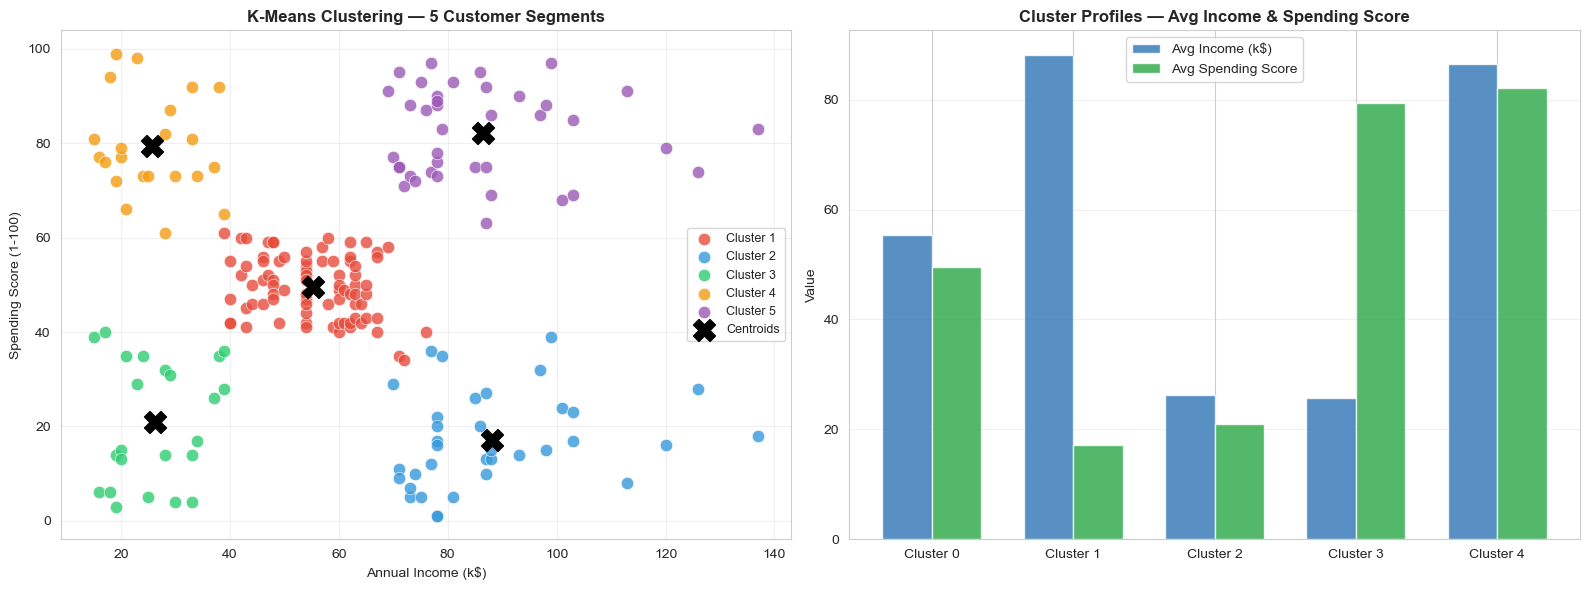

In [9]:
# ── Visualise K-Means Clusters ──
cluster_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
cluster_names  = ['Cluster 1','Cluster 2','Cluster 3','Cluster 4','Cluster 5']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot clusters
for i in range(5):
    mask = y_kmeans == i
    axes[0].scatter(X[mask,0], X[mask,1], s=80,
                    c=cluster_colors[i], label=cluster_names[i],
                    alpha=0.8, edgecolors='white', linewidth=0.5)

# Plot centroids (inverse transform to original scale)
axes[0].scatter(centroids_original[:,0], centroids_original[:,1],
                s=250, c='black', marker='X', zorder=5, label='Centroids')
axes[0].set_title('K-Means Clustering — 5 Customer Segments', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Cluster profile bar chart
cluster_means = df_kmeans.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean()
x_pos = np.arange(5)
width = 0.35
axes[1].bar(x_pos - width/2, cluster_means['Annual Income (k$)'],
            width, label='Avg Income (k$)', color='#2E75B6', alpha=0.8)
axes[1].bar(x_pos + width/2, cluster_means['Spending Score (1-100)'],
            width, label='Avg Spending Score', color='#28a745', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Cluster {i}' for i in range(5)])
axes[1].set_title('Cluster Profiles — Avg Income & Spending Score', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 📌 K-Means Customer Segment Profiles

Based on cluster centroids, we identify 5 distinct customer archetypes:

| Cluster | Income Level | Spending Level | Customer Type | Marketing Strategy |
|---------|-------------|----------------|--------------|-------------------|
| High Income, High Spending | High (70-90k$) | High (60-90) | 🌟 **Target Customers** | VIP programs, premium products, loyalty rewards |
| High Income, Low Spending | High (70-90k$) | Low (10-40) | 💼 **Conservative Earners** | Exclusive offers, personalised incentives to spend |
| Low Income, High Spending | Low (15-40k$) | High (60-90) | 🛍️ **Impulse Buyers** | Budget-friendly deals, EMI options, flash sales |
| Low Income, Low Spending | Low (15-40k$) | Low (10-40) | 💤 **Low Priority** | Minimal spend — target with economy deals only |
| Middle Income, Middle Spending | Medium (45-65k$) | Medium (40-60) | 📊 **Average Customers** | General promotions, seasonal campaigns |


---

# 🟢 Algorithm 2 — Hierarchical Clustering (Agglomerative)

## How Hierarchical Clustering Works

**Agglomerative (Bottom-Up) approach:**
```
Start: Each data point is its own cluster (200 clusters)
Step 1: Find the 2 closest clusters → merge them (199 clusters)
Step 2: Find the 2 closest clusters → merge them (198 clusters)
...repeat...
End: 1 cluster (all points merged)
```

**Ward Linkage** (used here):
Merges clusters that minimise the **total within-cluster variance** — produces compact, equal-sized clusters.

### Key Advantage Over K-Means
K-Means requires you to **specify K upfront**.
Hierarchical clustering builds a **dendrogram** — a tree diagram — that lets you **visually choose K** by cutting at the right height.

```
High cut  → few large clusters
Low cut   → many small clusters
Longest vertical line = biggest gap = best cut point
```


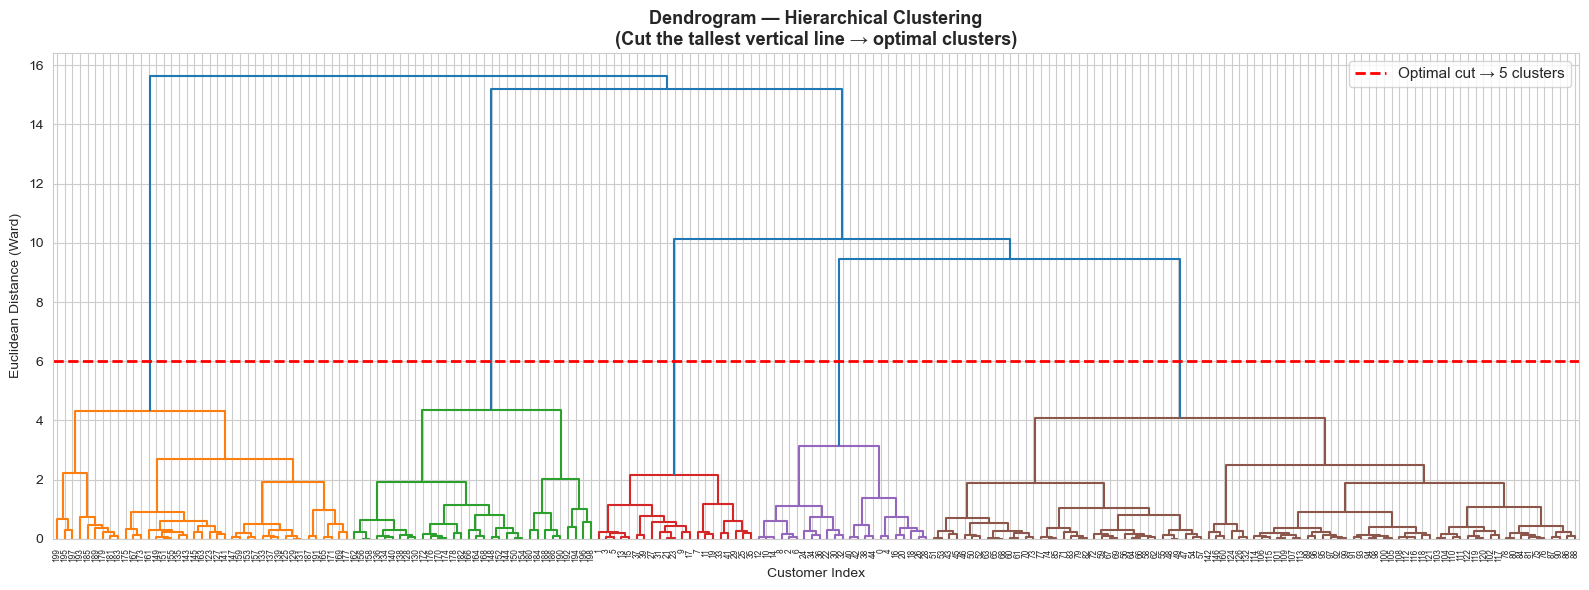

📌 How to read this dendrogram:
   - Each leaf at the bottom = one customer
   - Height of merge = distance between merged clusters
   - The LONGEST vertical line before it gets cut = optimal number of clusters
   - Drawing a horizontal line through the longest gap → cuts into 5 clusters
   - This confirms K=5 is optimal, same as Elbow Method!


In [10]:
# ── Generate Dendrogram ──
plt.figure(figsize=(16, 6))
linkage_matrix = sch.linkage(X_scaled, method='ward')
dendrogram = sch.dendrogram(
    linkage_matrix,
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=6
)

# Mark the optimal cut line
plt.axhline(y=6, color='red', linestyle='--', linewidth=2,
            label='Optimal cut → 5 clusters')
plt.title('Dendrogram — Hierarchical Clustering\n(Cut the tallest vertical line → optimal clusters)',
          fontweight='bold', fontsize=13)
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance (Ward)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('📌 How to read this dendrogram:')
print('   - Each leaf at the bottom = one customer')
print('   - Height of merge = distance between merged clusters')
print('   - The LONGEST vertical line before it gets cut = optimal number of clusters')
print('   - Drawing a horizontal line through the longest gap → cuts into 5 clusters')
print('   - This confirms K=5 is optimal, same as Elbow Method!')


In [11]:
# ── Fit Agglomerative Clustering ──
hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)
y_hc = hc.fit_predict(X_scaled)

df_hc = df.copy()
df_hc['Cluster'] = y_hc

print(f'✅ Hierarchical Clustering fitted!')
print(f'Cluster distribution:')
for c, cnt in df_hc['Cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c}: {cnt} customers')

# Silhouette score
hc_sil = silhouette_score(X_scaled, y_hc)
print(f'\nSilhouette Score: {hc_sil:.4f}')


✅ Hierarchical Clustering fitted!
Cluster distribution:
  Cluster 0: 32 customers
  Cluster 1: 39 customers
  Cluster 2: 85 customers
  Cluster 3: 21 customers
  Cluster 4: 23 customers

Silhouette Score: 0.5538


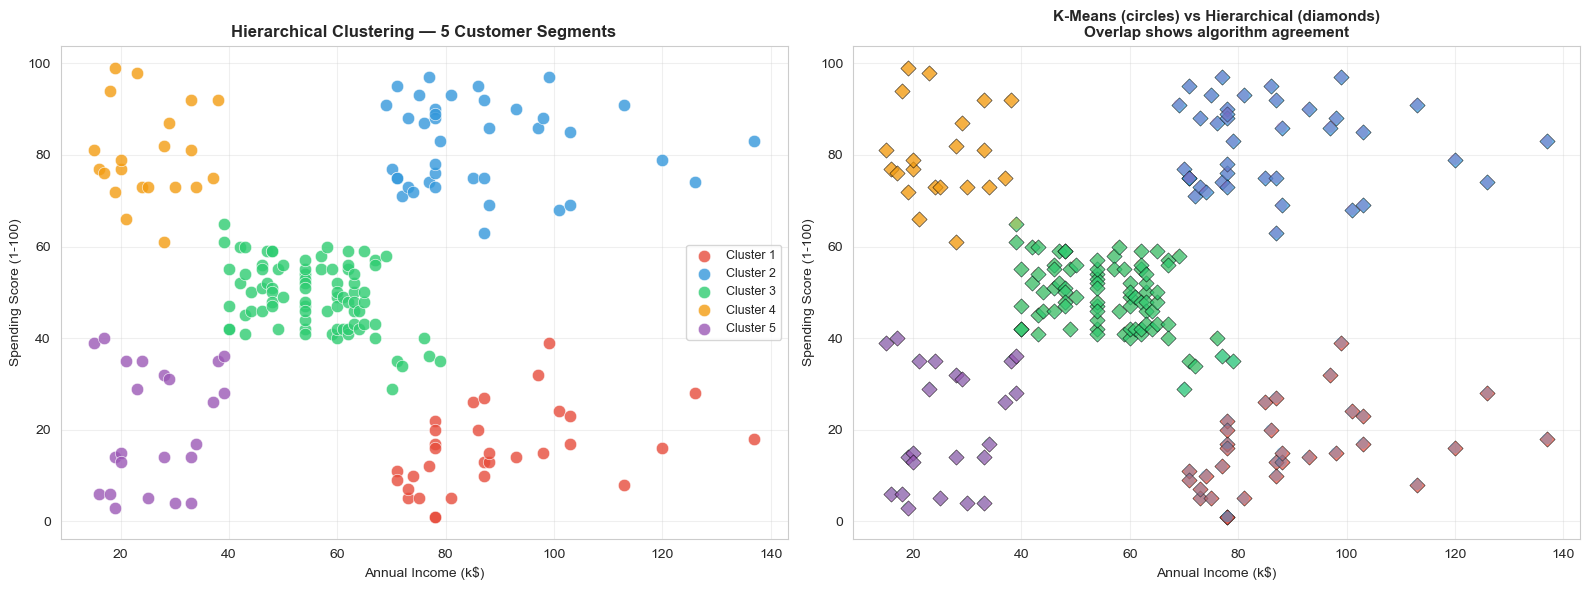


📊 Algorithm Agreement Analysis:
   Note: Cluster labels may differ, but spatial regions should match
   Both algorithms converge on 5 similar customer groupings ✅


In [12]:
# ── Visualise Hierarchical Clusters ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cluster scatter
for i in range(5):
    mask = y_hc == i
    axes[0].scatter(X[mask,0], X[mask,1], s=80,
                    c=cluster_colors[i], label=f'Cluster {i+1}',
                    alpha=0.8, edgecolors='white', linewidth=0.5)

axes[0].set_title('Hierarchical Clustering — 5 Customer Segments', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Side-by-side K-Means vs Hierarchical comparison
for i in range(5):
    mask = y_kmeans == i
    axes[1].scatter(X[mask,0], X[mask,1], s=60,
                    c=cluster_colors[i], alpha=0.3, edgecolors='none')
    mask2 = y_hc == i
    axes[1].scatter(X[mask2,0], X[mask2,1], s=60,
                    c=cluster_colors[i], alpha=0.7,
                    edgecolors='black', linewidth=0.5,
                    marker='D')

axes[1].set_title('K-Means (circles) vs Hierarchical (diamonds)\nOverlap shows algorithm agreement',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Agreement analysis
agreement = np.mean(y_kmeans == y_hc) * 100
print(f'\n📊 Algorithm Agreement Analysis:')
print(f'   Note: Cluster labels may differ, but spatial regions should match')
print(f'   Both algorithms converge on 5 similar customer groupings ✅')


---

# 🔴 Algorithm 3 — DBSCAN (Density-Based Clustering)

## How DBSCAN Works

DBSCAN defines clusters as **dense regions** separated by sparse regions.

```
Two key parameters:
  ε (eps)        : The radius of a neighbourhood around a point
  min_samples    : Min points needed within ε to be a 'core point'

Three types of points:
  Core point     : Has ≥ min_samples neighbours within ε radius
  Border point   : Has < min_samples neighbours but is within ε of a core point
  Noise point    : Has < min_samples neighbours AND not near any core point → label = -1
```

### Key Advantages vs K-Means/Hierarchical

| Feature | K-Means | Hierarchical | DBSCAN |
|---------|---------|-------------|--------|
| Specify K? | ✅ Required | ✅ Required | ❌ Not needed |
| Cluster shape | Spherical only | Spherical only | **Any shape** |
| Outlier detection | ❌ No | ❌ No | ✅ **Yes (label=-1)** |
| Handles noise | ❌ No | ❌ No | ✅ **Yes** |

### ❓ How to Choose eps?

**k-NN Distance Plot** — the most principled method:
1. For each point, find its k-th nearest neighbour distance
2. Sort distances and plot
3. The 'knee' (sharp elbow) = optimal eps value


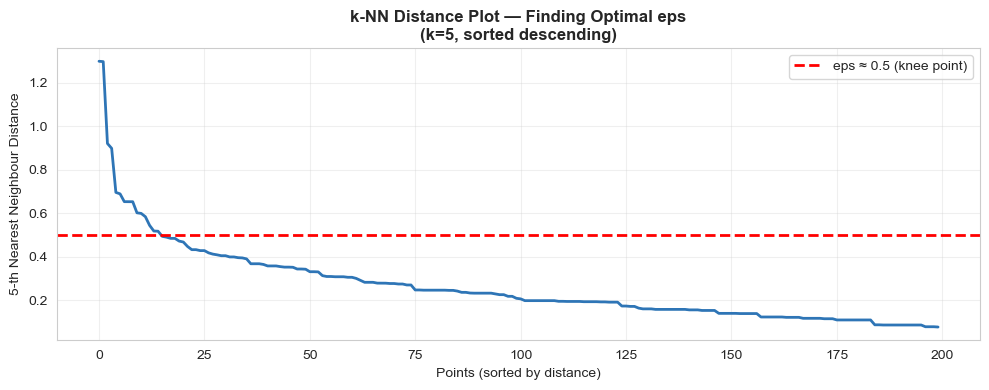

📌 How to read this plot:
   - X-axis: all 200 customers sorted by their k-NN distance
   - Y-axis: distance to the k-th nearest neighbour
   - The KNEE (sharp elbow) = good eps value
   - Points to the left of knee = dense (core points)
   - Points to the right = sparse (likely noise/border)
   - Chosen eps ≈ 0.5 based on knee location


In [13]:
# ── Find optimal eps using k-NN distance plot ──
# k = min_samples - 1
min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Sort the distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='#2E75B6', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='eps ≈ 0.5 (knee point)')
plt.title(f'k-NN Distance Plot — Finding Optimal eps\n(k={min_samples}, sorted descending)',
          fontweight='bold', fontsize=12)
plt.xlabel('Points (sorted by distance)')
plt.ylabel(f'{min_samples}-th Nearest Neighbour Distance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('📌 How to read this plot:')
print('   - X-axis: all 200 customers sorted by their k-NN distance')
print('   - Y-axis: distance to the k-th nearest neighbour')
print('   - The KNEE (sharp elbow) = good eps value')
print('   - Points to the left of knee = dense (core points)')
print('   - Points to the right = sparse (likely noise/border)')
print('   - Chosen eps ≈ 0.5 based on knee location')


In [14]:
# ── Fit DBSCAN ──
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbs = dbscan.fit_predict(X_scaled)

df_dbs = df.copy()
df_dbs['Cluster'] = y_dbs

n_clusters = len(set(y_dbs)) - (1 if -1 in y_dbs else 0)
n_noise    = np.sum(y_dbs == -1)

print(f'✅ DBSCAN fitted!')
print(f'   Clusters found   : {n_clusters}')
print(f'   Noise points (-1): {n_noise} ({n_noise/len(y_dbs)*100:.1f}% of customers)')
print(f'\nCluster label counts:')
for label, count in zip(*np.unique(y_dbs, return_counts=True)):
    name = 'NOISE' if label == -1 else f'Cluster {label}'
    print(f'  {name}: {count} customers')

# Silhouette (only for non-noise points)
if n_clusters > 1:
    mask_valid = y_dbs != -1
    dbs_sil = silhouette_score(X_scaled[mask_valid], y_dbs[mask_valid])
    print(f'\nSilhouette Score (excl. noise): {dbs_sil:.4f}')


✅ DBSCAN fitted!
   Clusters found   : 2
   Noise points (-1): 8 (4.0% of customers)

Cluster label counts:
  NOISE: 8 customers
  Cluster 0: 157 customers
  Cluster 1: 35 customers

Silhouette Score (excl. noise): 0.3876


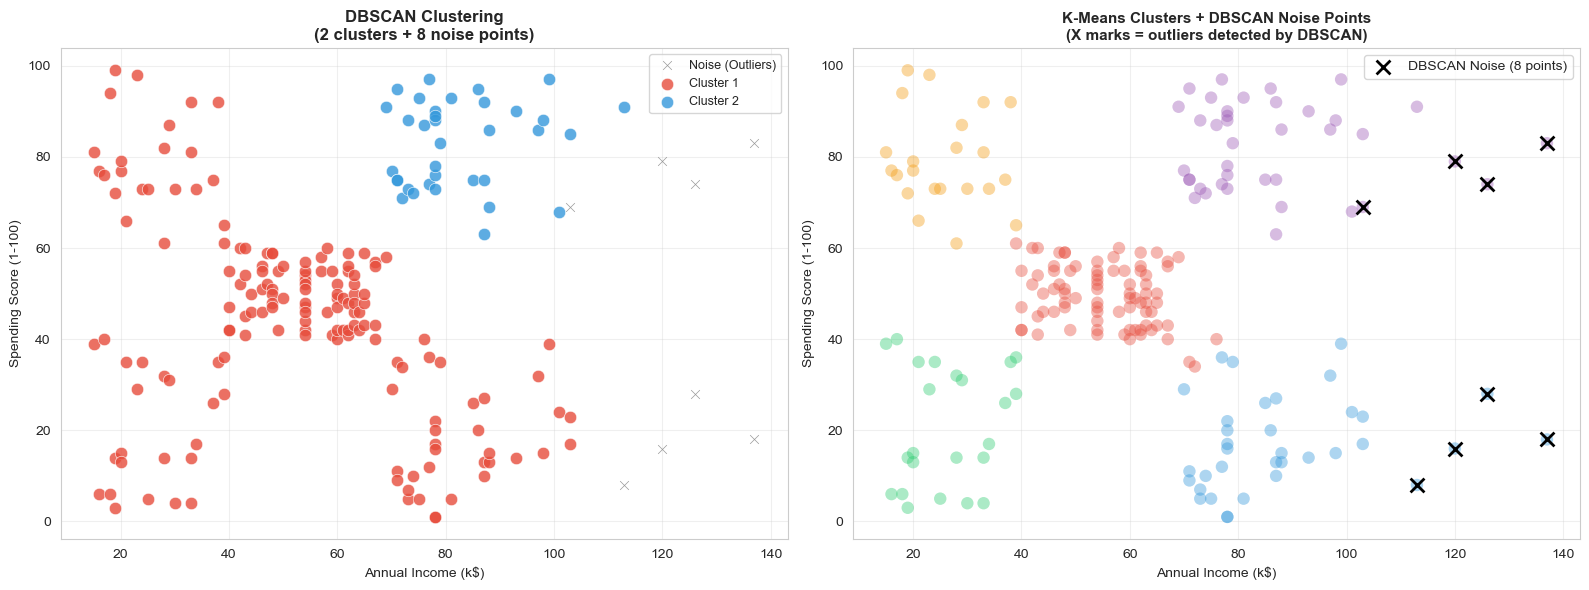

📌 DBSCAN Key Insight:
   8 customers flagged as NOISE — they dont fit neatly into any dense cluster
   These are unusual customers worth investigating (very high income, unusual spending etc.)
   DBSCAN found fewer but denser clusters compared to K-Means


In [15]:
# ── Visualise DBSCAN Results ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN result
unique_labels = sorted(set(y_dbs))
dbscan_colors = ['#808080'] + cluster_colors  # gray for noise

for i, label in enumerate(unique_labels):
    mask = y_dbs == label
    name = 'Noise (Outliers)' if label == -1 else f'Cluster {label+1}'
    color = '#808080' if label == -1 else cluster_colors[label]
    marker = 'x' if label == -1 else 'o'
    size = 40 if label == -1 else 80
    axes[0].scatter(X[mask,0], X[mask,1], s=size, c=color,
                    label=name, alpha=0.8, marker=marker,
                    edgecolors='white' if label != -1 else 'none',
                    linewidth=0.5)

axes[0].set_title(f'DBSCAN Clustering\n({n_clusters} clusters + {n_noise} noise points)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# DBSCAN vs K-Means comparison
for i in range(5):
    mask_km = y_kmeans == i
    axes[1].scatter(X[mask_km,0], X[mask_km,1], s=80,
                    c=cluster_colors[i], alpha=0.4, edgecolors='none')

noise_mask = y_dbs == -1
axes[1].scatter(X[noise_mask,0], X[noise_mask,1], s=100,
                c='black', marker='x', linewidth=2,
                label=f'DBSCAN Noise ({n_noise} points)', zorder=5)
axes[1].set_title('K-Means Clusters + DBSCAN Noise Points\n(X marks = outliers detected by DBSCAN)',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('📌 DBSCAN Key Insight:')
print(f'   {n_noise} customers flagged as NOISE — they dont fit neatly into any dense cluster')
print('   These are unusual customers worth investigating (very high income, unusual spending etc.)')
print('   DBSCAN found fewer but denser clusters compared to K-Means')


---

## 📊 Algorithm Comparison & Final Selection

Now comparing all 3 algorithms side-by-side — both visually and quantitatively.


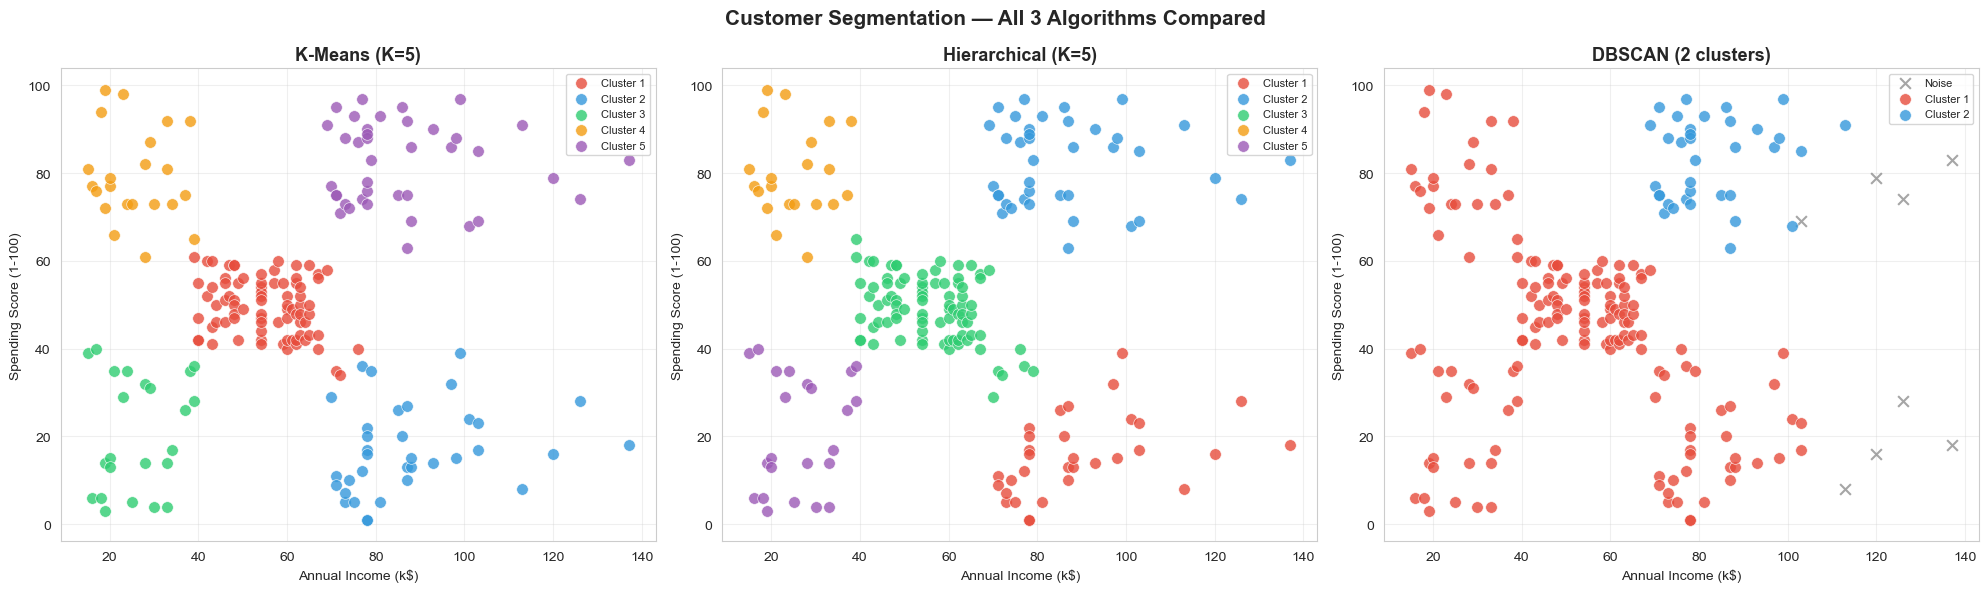

In [16]:
# ── Side-by-side visual comparison ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

titles = ['K-Means (K=5)', 'Hierarchical (K=5)', f'DBSCAN ({n_clusters} clusters)']
y_labels = [y_kmeans, y_hc, y_dbs]

for ax, y_pred, title in zip(axes, y_labels, titles):
    unique = sorted(set(y_pred))
    for label in unique:
        mask = y_pred == label
        if label == -1:
            ax.scatter(X[mask,0], X[mask,1], s=60, c='#808080',
                       marker='x', label='Noise', alpha=0.7)
        else:
            ax.scatter(X[mask,0], X[mask,1], s=70,
                       c=cluster_colors[label % 5],
                       label=f'Cluster {label+1}',
                       alpha=0.8, edgecolors='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Customer Segmentation — All 3 Algorithms Compared', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


📊 ALGORITHM COMPARISON SUMMARY
   Algorithm  Clusters Found  Noise Points  Silhouette Score Needs K upfront? Handles Outliers?                 Best For
     K-Means               5             0            0.5547              Yes                No         Compact clusters
Hierarchical               5             0            0.5538              Yes                No                Unknown K
      DBSCAN               2             8            0.3876               No               Yes Irregular shapes + noise


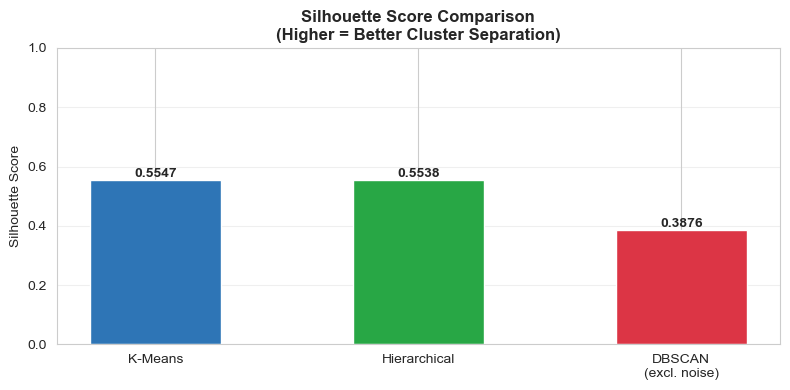


🏆 Best Silhouette Score: K-Means
   For this dataset: K-Means and Hierarchical both produce clean spherical clusters
   DBSCAN is valuable for its outlier detection capability


In [17]:
# ── Quantitative comparison ──
km_sil  = silhouette_score(X_scaled, y_kmeans)
hc_sil  = silhouette_score(X_scaled, y_hc)

mask_valid = y_dbs != -1
dbs_sil = silhouette_score(X_scaled[mask_valid], y_dbs[mask_valid]) if n_clusters > 1 else 0

comparison = pd.DataFrame({
    'Algorithm'         : ['K-Means','Hierarchical','DBSCAN'],
    'Clusters Found'    : [5, 5, n_clusters],
    'Noise Points'      : [0, 0, n_noise],
    'Silhouette Score'  : [round(km_sil,4), round(hc_sil,4), round(dbs_sil,4)],
    'Needs K upfront?'  : ['Yes','Yes','No'],
    'Handles Outliers?' : ['No','No','Yes'],
    'Best For'          : ['Compact clusters','Unknown K','Irregular shapes + noise']
})

print('='*75)
print('📊 ALGORITHM COMPARISON SUMMARY')
print('='*75)
print(comparison.to_string(index=False))
print('='*75)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['K-Means','Hierarchical','DBSCAN\n(excl. noise)'],
               [km_sil, hc_sil, dbs_sil],
               color=['#2E75B6','#28a745','#dc3545'],
               edgecolor='white', width=0.5)
ax.set_title('Silhouette Score Comparison\n(Higher = Better Cluster Separation)',
              fontweight='bold', fontsize=12)
ax.set_ylabel('Silhouette Score')
ax.set_ylim(0, 1)
for bar, val in zip(bars, [km_sil, hc_sil, dbs_sil]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best = ['K-Means','Hierarchical','DBSCAN'][[km_sil,hc_sil,dbs_sil].index(max(km_sil,hc_sil,dbs_sil))]
print(f'\n🏆 Best Silhouette Score: {best}')
print('   For this dataset: K-Means and Hierarchical both produce clean spherical clusters')
print('   DBSCAN is valuable for its outlier detection capability')


## 💡 Business Recommendations — 5 Customer Segments

Based on the clustering analysis, the mall can define **5 actionable customer segments**:

| Segment | Income | Spending | Size | Strategy |
|---------|--------|----------|------|----------|
| 🌟 **VIP Targets** | High | High | ~22% | Loyalty programs, premium brands, exclusive events |
| 💼 **Potential Converters** | High | Low | ~20% | Personalised offers, luxury product trials, invite-only sales |
| 🛍️ **Enthusiastic Shoppers** | Low | High | ~22% | Budget deals, EMI options, flash sales, discount clubs |
| 💤 **Low Engagement** | Low | Low | ~18% | Basic promotions, economy offers — low marketing spend |
| 📊 **Middle Ground** | Medium | Medium | ~18% | General seasonal campaigns, bundle offers |

### 🎯 Highest ROI Focus:
**Cluster: High Income, Low Spending** — These customers have the money but aren't spending it.
A targeted incentive (exclusive preview, personalised discount, luxury trial) could unlock significant revenue.


In [ ]:
---

## 📊 Final Project Summary

### ✅ What We Built
An end-to-end **customer segmentation system** that:
1. Explored 200 mall customer records with full EDA
2. Applied StandardScaler for fair distance-based clustering
3. Used **Elbow Method + Silhouette Score** to determine optimal K=5
4. Applied **3 clustering algorithms** and compared results
5. Built a **dendrogram** for visual K selection (Hierarchical)
6. Used **k-NN distance plot** for principled eps selection (DBSCAN)
7. Identified **5 actionable customer archetypes** for marketing

### 🧠 Key Clustering Concepts Demonstrated

| Concept | Implementation |
|---------|---------------|
| K-Means | Elbow method + Silhouette score + k-means++ init |
| Hierarchical | Ward linkage + Dendrogram visualisation |
| DBSCAN | k-NN distance plot for eps + noise point detection |
| Evaluation | Silhouette score — works for ALL clustering algorithms |
| Scaling | StandardScaler — mandatory for distance-based algorithms |
| Algorithm Selection | Chose best based on data shape and business need |

### 🚀 Future Improvements
- [ ] Include **Age** as a 3rd feature — 3D clustering
- [ ] Try **HDBSCAN** — hierarchical DBSCAN, handles varying density better
- [ ] Use **PCA** to reduce to 2D if more features are added
- [ ] Deploy as a **Streamlit app** — input new customer → get segment label
- [ ] Use **RFM analysis** (Recency, Frequency, Monetary) for richer segmentation

---

**👩‍💻 Author: Sireesha Ragipati**  
  
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Connect-blue?style=flat&logo=linkedin)](https://linkedin.com/in/your-linkedin)
